In [1]:
pip install xarray netCDF4 matplotlib cartopy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.ops import unary_union
from matplotlib.path import Path
from matplotlib.lines import Line2D
 
base = r"D:/asd390/delhi_ground_atmos_project/week_5/"

# Wind speed
ds_wind = xr.open_mfdataset(
    [
        base + "ERA5_WS_daily_2021.nc",
        base + "ERA5_WS_daily_2022_2024.nc",
    ],
    combine="by_coords"
)

# 2m temperature
ds_t2m = xr.open_dataset(base + "era5_daily_t2m_2021_2024.nc")

# 925 hPa temperature
ds_t925 = xr.open_dataset(base + "era5_daily_t925hpa_2021_2024.nc")

# Total precipitation
ds_tp = xr.open_dataset(base + "era5_daily_tp_2021_2024.nc")
 
# Quick sanity check — print all variable names
print("Wind variables:", list(ds_wind.data_vars))
print("T2m variables:", list(ds_t2m.data_vars))
print("T925 variables:", list(ds_t925.data_vars))
print("TP variables:", list(ds_tp.data_vars))

Wind variables: ['ws10m', 'ws100m']
T2m variables: ['time_bnds', '2t']
T925 variables: ['time_bnds', 't']
TP variables: ['time_bnds', 'tp']


In [8]:
print("Wind coords:", list(ds_wind.coords))
print("T2m coords:", list(ds_t2m.coords))
print("T925 coords:", list(ds_t925.coords))
print("TP coords:", list(ds_tp.coords))

Wind coords: ['time', 'longitude', 'latitude']
T2m coords: ['time', 'lon', 'lat']
T925 coords: ['time', 'lon', 'lat', 'plev']
TP coords: ['time', 'lon', 'lat']


In [6]:
india = gpd.read_file(
    r"D:\downloads\ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp"
)
delhi = india[india["name"].str.contains("Delhi", case=False, na=False)].copy()
delhi = delhi.to_crs(epsg=4326)
delhi_geom = unary_union(delhi.geometry)
minx, miny, maxx, maxy = delhi.total_bounds
 
pad = 0.05
LAT = (miny - pad, maxy + pad)
LON = (minx - pad, maxx + pad)
 
print(f"\nDelhi bounding box: LAT {LAT}, LON {LON}")


Delhi bounding box: LAT (28.382605902840123, 28.932087511129726), LON (76.78368777866804, 77.38753299275338)


In [9]:
# Rename coordinates to match wind file
ds_t2m  = ds_t2m.rename({"lat": "latitude", "lon": "longitude"})
ds_t925 = ds_t925.rename({"lat": "latitude", "lon": "longitude"})
ds_tp   = ds_tp.rename({"lat": "latitude", "lon": "longitude"})

# T925 has a pressure level dimension (925 hPa) — squeeze it out
ds_t925 = ds_t925.squeeze("plev", drop=True)

In [10]:
wind_delhi = ds_wind.sel(
    latitude=slice(LAT[1], LAT[0]),
    longitude=slice(LON[0], LON[1])
)
 
t2m_delhi = ds_t2m.sel(
    latitude=slice(LAT[1], LAT[0]),
    longitude=slice(LON[0], LON[1])
)
 
t925_delhi = ds_t925.sel(
    latitude=slice(LAT[1], LAT[0]),
    longitude=slice(LON[0], LON[1])
)
 
tp_delhi = ds_tp.sel(
    latitude=slice(LAT[1], LAT[0]),
    longitude=slice(LON[0], LON[1])
)
 
print(f"\nERA5 grid cells in Delhi — lat: {wind_delhi.latitude.values}")
print(f"ERA5 grid cells in Delhi — lon: {wind_delhi.longitude.values}")
print(f"Total ERA5 cells: {len(wind_delhi.latitude) * len(wind_delhi.longitude)}")
 
# 🔄 NEW: Verify time alignment
print(f"\nTime ranges:")
print(f"  Wind:  {wind_delhi.time.values[0]}  to  {wind_delhi.time.values[-1]}  ({len(wind_delhi.time)} days)")
print(f"  T2m:   {t2m_delhi.time.values[0]}  to  {t2m_delhi.time.values[-1]}  ({len(t2m_delhi.time)} days)")
print(f"  T925:  {t925_delhi.time.values[0]}  to  {t925_delhi.time.values[-1]}  ({len(t925_delhi.time)} days)")
print(f"  TP:    {tp_delhi.time.values[0]}  to  {tp_delhi.time.values[-1]}  ({len(tp_delhi.time)} days)")
 
# 🔄 NEW: Align all datasets to the same time range (2021-2024)
common_start = "2021-01-01"
common_end   = "2024-12-31"
 
wind_delhi = wind_delhi.sel(time=slice(common_start, common_end))
t2m_delhi  = t2m_delhi.sel(time=slice(common_start, common_end))
t925_delhi = t925_delhi.sel(time=slice(common_start, common_end))
tp_delhi   = tp_delhi.sel(time=slice(common_start, common_end))
 
print(f"\nAfter alignment — all datasets: {len(wind_delhi.time)} days")



ERA5 grid cells in Delhi — lat: [28.75 28.5 ]
ERA5 grid cells in Delhi — lon: [77.   77.25]
Total ERA5 cells: 4

Time ranges:
  Wind:  2021-01-01T00:00:00.000000000  to  2024-12-31T00:00:00.000000000  (1461 days)
  T2m:   2021-01-01T11:30:00.000000000  to  2024-12-31T11:30:00.000000000  (1461 days)
  T925:  2021-01-01T11:30:00.000000000  to  2024-12-31T11:30:00.000000000  (1461 days)
  TP:    2021-01-01T11:30:00.000000000  to  2024-12-31T11:30:00.000000000  (1461 days)

After alignment — all datasets: 1461 days


In [13]:
# Strip time-of-day so all datasets align on DATE only
wind_delhi = wind_delhi.assign_coords(time=wind_delhi.time.dt.floor("D"))
t2m_delhi  = t2m_delhi.assign_coords(time=t2m_delhi.time.dt.floor("D"))
t925_delhi = t925_delhi.assign_coords(time=t925_delhi.time.dt.floor("D"))
tp_delhi   = tp_delhi.assign_coords(time=tp_delhi.time.dt.floor("D"))

In [14]:
WS_THRESHOLD = 3.2     # m/s  (from NOAA / Wang & Angell 1999)
TP_THRESHOLD = 0.001   # metres (ERA5 stores precip in m; 1mm = 0.001m)
 
# Build individual condition masks
cond_wind      = wind_delhi["ws10m"] < WS_THRESHOLD
cond_inversion = (t925_delhi["t"] - t2m_delhi["2t"]) > 0   # warm air above = lid
cond_dry       = tp_delhi["tp"] < TP_THRESHOLD
 
# 🔄 NEW: Combined India-ASI-inspired stagnation mask (all three must be true)
stagnant_mask = cond_wind & cond_inversion & cond_dry
 
# 🔄 NEW: Print diagnostics — how many stagnant days per condition
total_days = len(wind_delhi.time)
print(f"\n--- Stagnation Diagnostics (domain-averaged) ---")
print(f"Total days: {total_days}")
print(f"Days with calm wind (ws10m < {WS_THRESHOLD}):     {float(cond_wind.mean()) * 100:.1f}%")
print(f"Days with inversion (T925 > T2m):                 {float(cond_inversion.mean()) * 100:.1f}%")
print(f"Days with no rain (precip < 1mm):                 {float(cond_dry.mean()) * 100:.1f}%")
print(f"Days meeting ALL 3 (India-ASI stagnant):          {float(stagnant_mask.mean()) * 100:.1f}%")
print(f"")
print(f"For comparison — old method (wind only):          {float(cond_wind.mean()) * 100:.1f}%")
print(f"New method is stricter by:                        {(float(cond_wind.mean()) - float(stagnant_mask.mean())) * 100:.1f} percentage points")


--- Stagnation Diagnostics (domain-averaged) ---
Total days: 1461
Days with calm wind (ws10m < 3.2):     87.5%
Days with inversion (T925 > T2m):                 16.5%
Days with no rain (precip < 1mm):                 50.2%
Days meeting ALL 3 (India-ASI stagnant):          13.4%

For comparison — old method (wind only):          87.5%
New method is stricter by:                        74.1 percentage points


Stagnant count shape: (20, 2, 2)
Months present: [ 1  2 10 11 12]
Years present:  [2021 2022 2023 2024]

Sample values (Oct 2021):
[[[1 0]
  [0 0]]]

[2021-10] ERA5 raw anomaly values: [-0.75 -1.25 -0.5  -1.25]
  range: -1.250 to -0.500 stagnant days


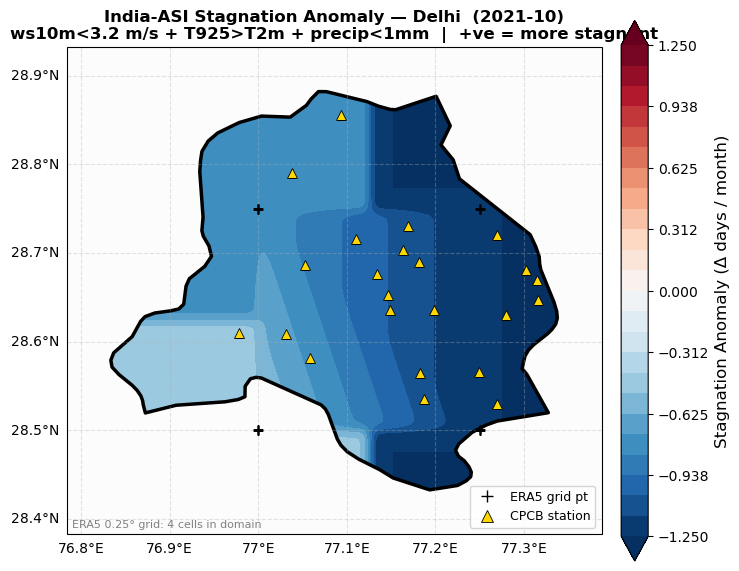


[2021-11] ERA5 raw anomaly values: [7.   7.25 6.5  8.  ]
  range: 6.500 to 8.000 stagnant days


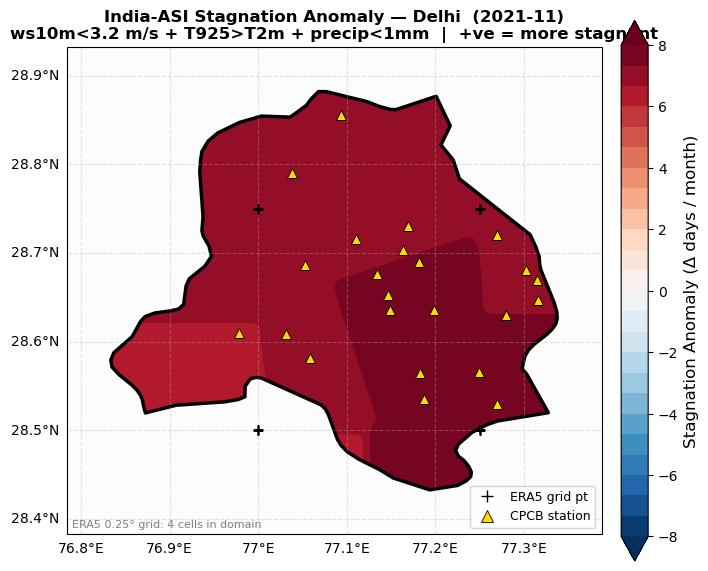


[2021-12] ERA5 raw anomaly values: [-8.75 -9.   -7.75 -8.75]
  range: -9.000 to -7.750 stagnant days


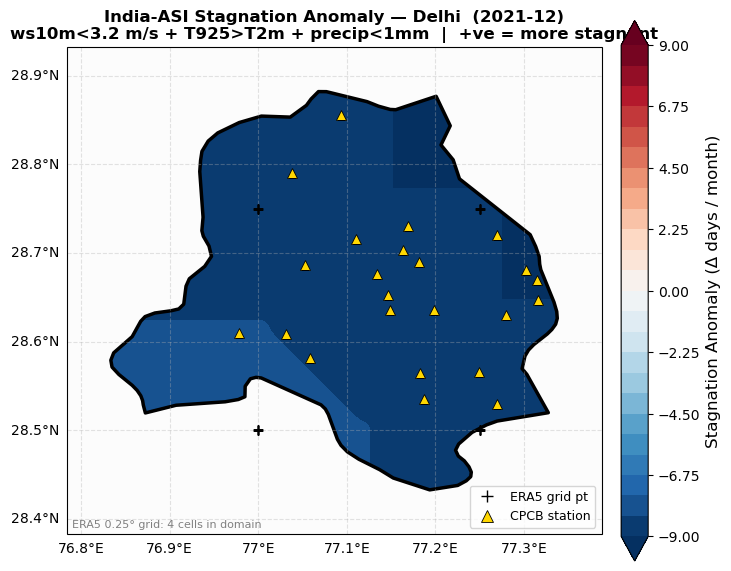


[2021-01] ERA5 raw anomaly values: [ 1.5   0.75  1.5  -1.75]
  range: -1.750 to 1.500 stagnant days


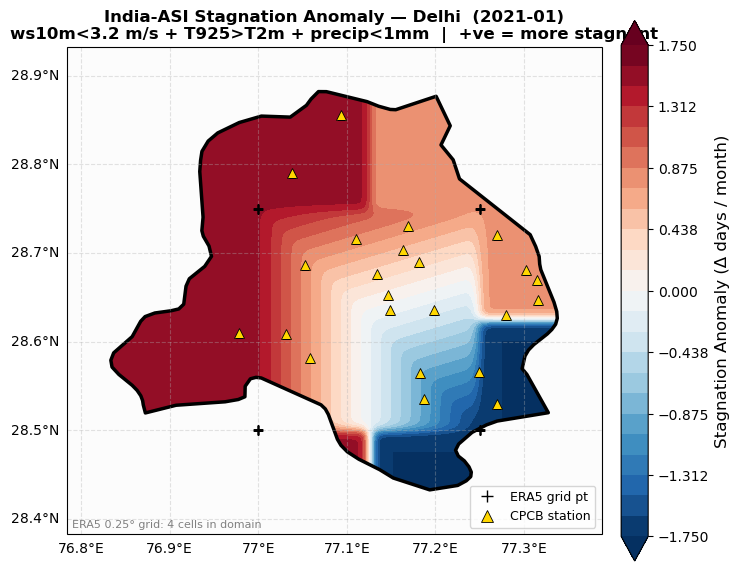


[2021-02] ERA5 raw anomaly values: [3.25 1.   0.75 1.  ]
  range: 0.750 to 3.250 stagnant days


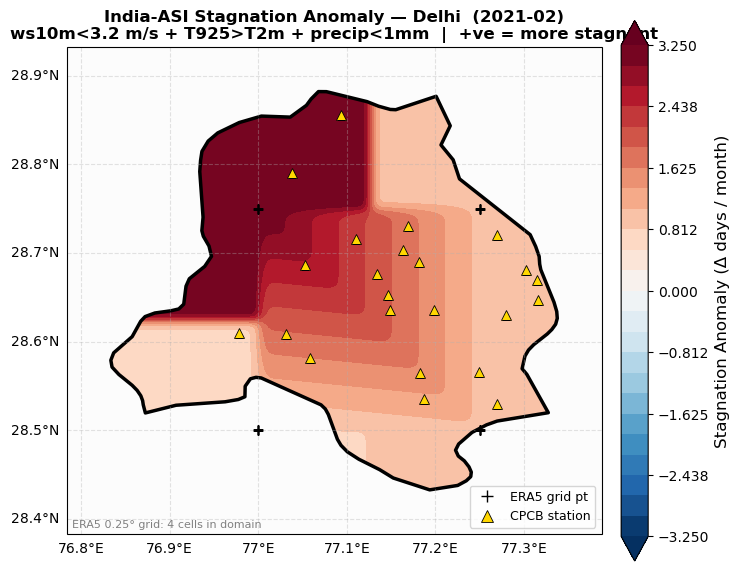


[2022-10] ERA5 raw anomaly values: [ 1.25 -0.25  0.5  -0.25]
  range: -0.250 to 1.250 stagnant days


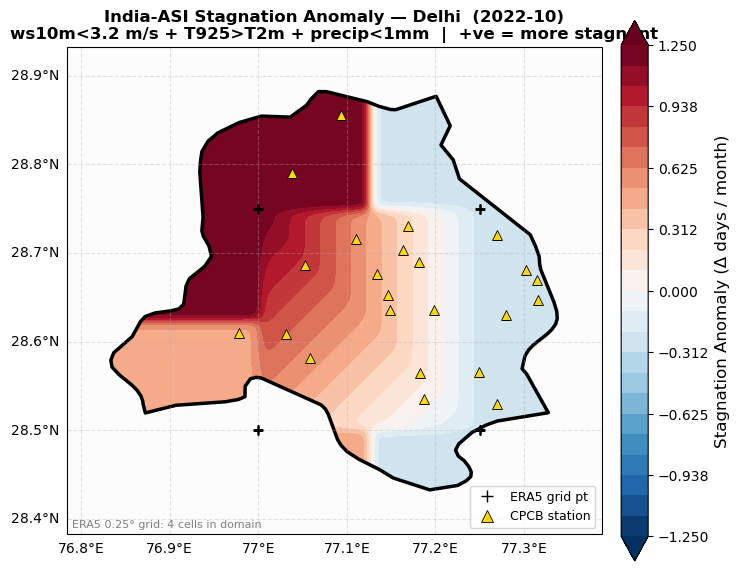


[2022-11] ERA5 raw anomaly values: [1.   2.25 2.5  2.  ]
  range: 1.000 to 2.500 stagnant days


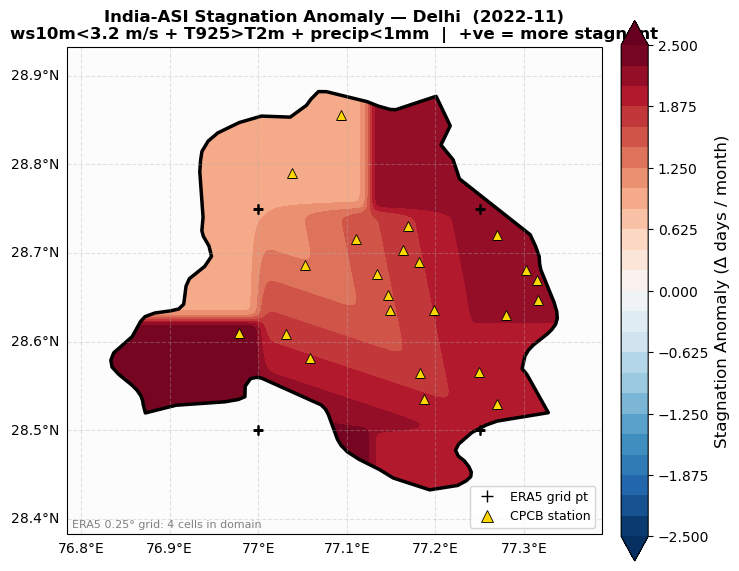


[2022-12] ERA5 raw anomaly values: [3.25 5.   6.25 5.25]
  range: 3.250 to 6.250 stagnant days


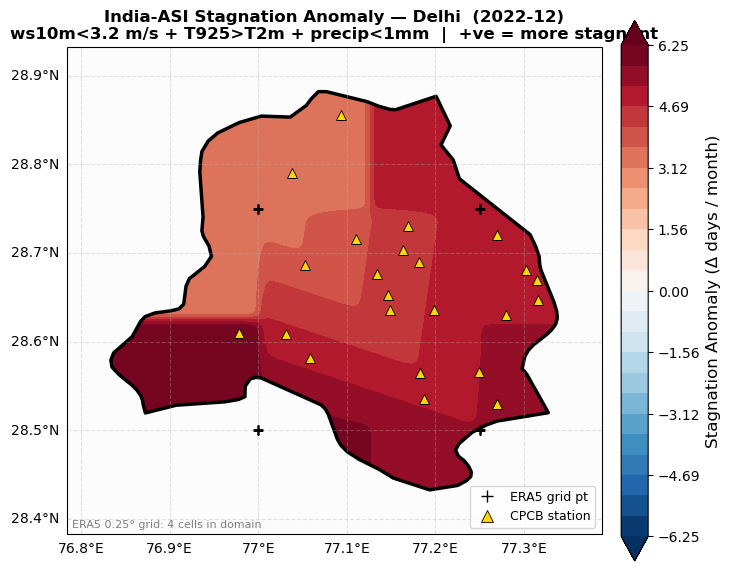


[2022-01] ERA5 raw anomaly values: [-5.5  -5.25 -5.5  -6.75]
  range: -6.750 to -5.250 stagnant days


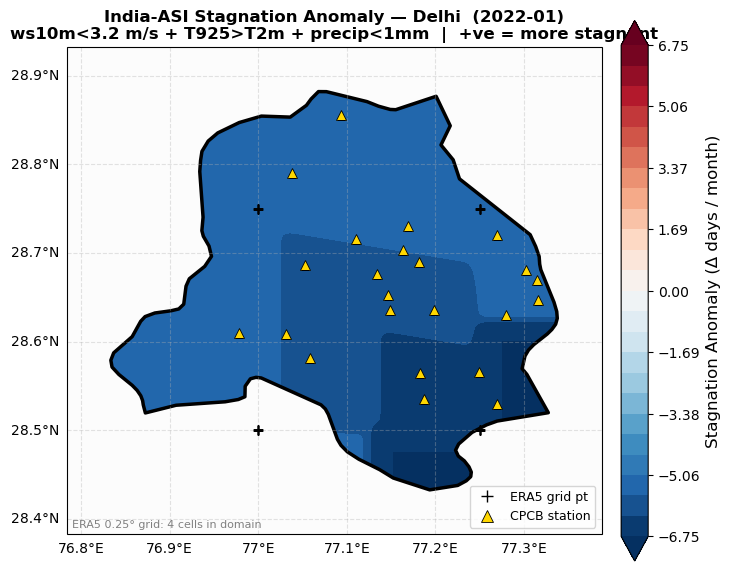


[2022-02] ERA5 raw anomaly values: [-6.75 -4.   -4.25 -4.  ]
  range: -6.750 to -4.000 stagnant days


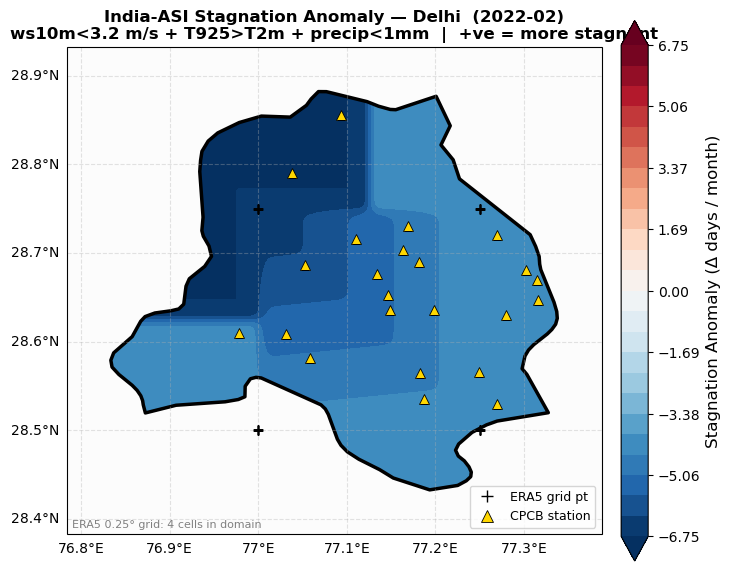


[2023-10] ERA5 raw anomaly values: [1.25 1.75 0.5  2.75]
  range: 0.500 to 2.750 stagnant days


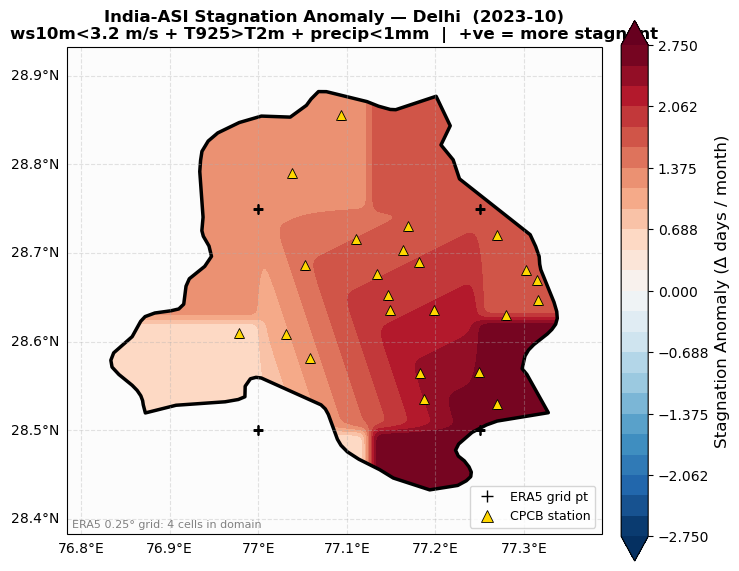


[2023-11] ERA5 raw anomaly values: [-3.   -5.75 -3.5  -4.  ]
  range: -5.750 to -3.000 stagnant days


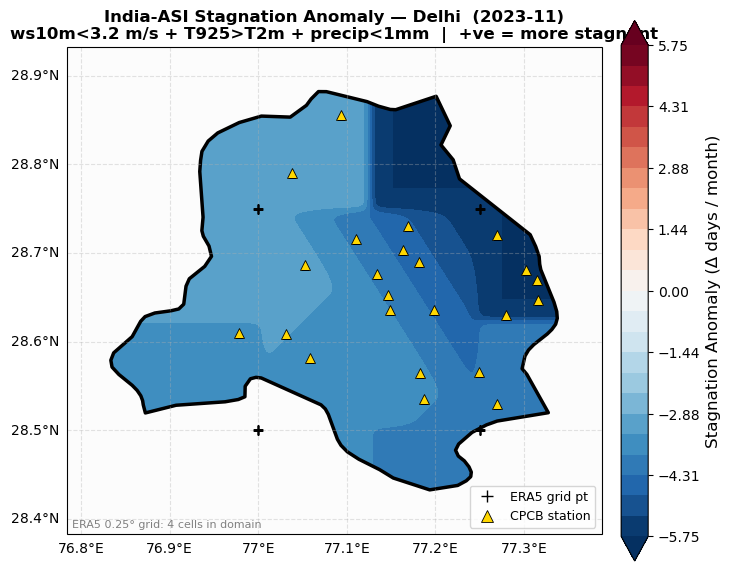


[2023-12] ERA5 raw anomaly values: [3.25 3.   3.25 4.25]
  range: 3.000 to 4.250 stagnant days


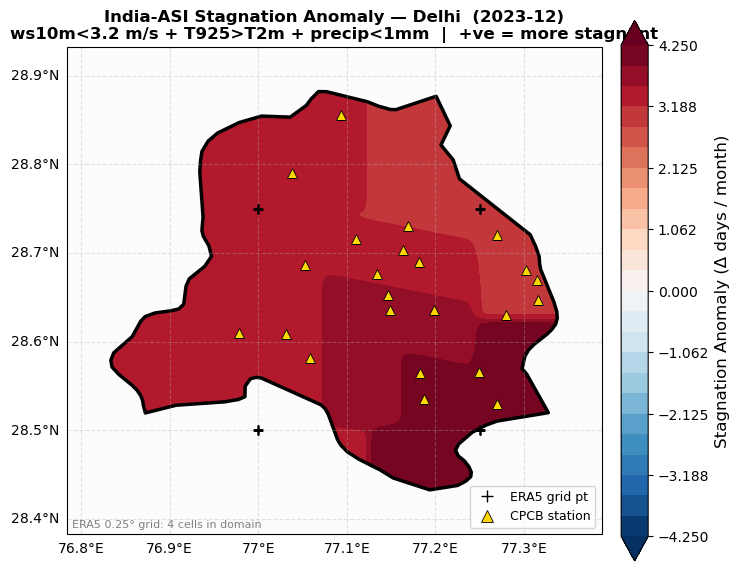


[2023-01] ERA5 raw anomaly values: [-3.5  -4.25 -3.5  -2.75]
  range: -4.250 to -2.750 stagnant days


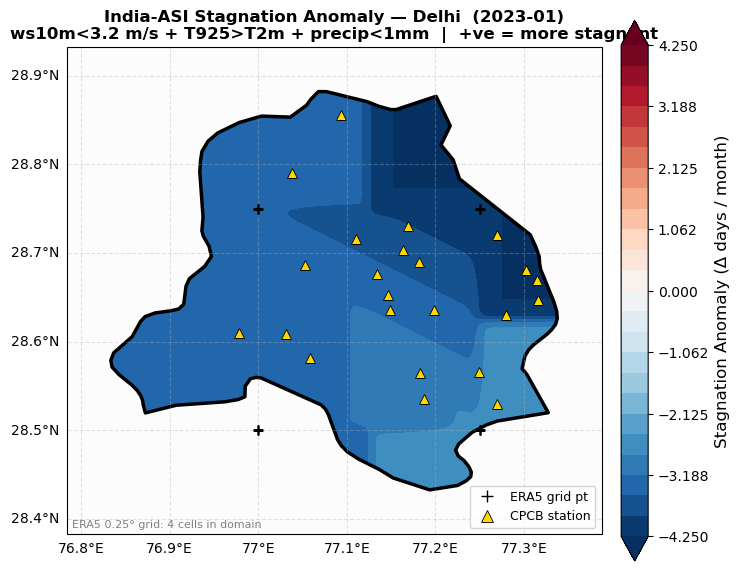


[2023-02] ERA5 raw anomaly values: [8.25 8.   6.75 7.  ]
  range: 6.750 to 8.250 stagnant days


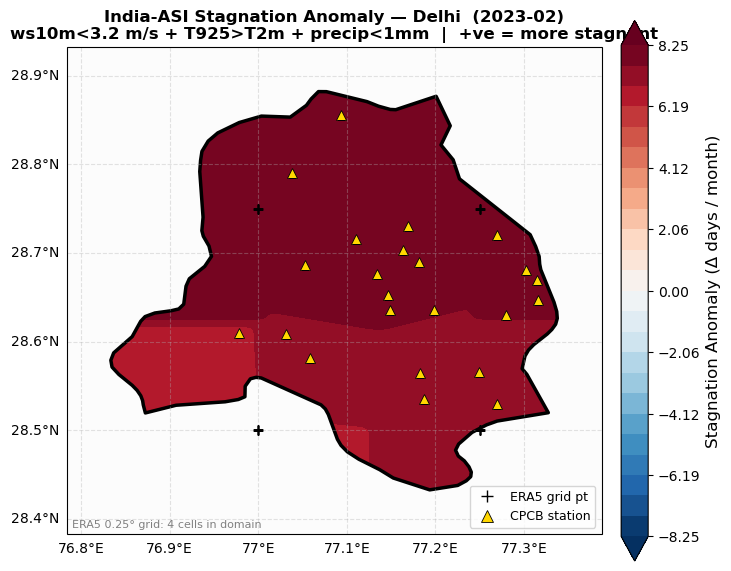


[2024-10] ERA5 raw anomaly values: [-1.75 -0.25 -0.5  -1.25]
  range: -1.750 to -0.250 stagnant days


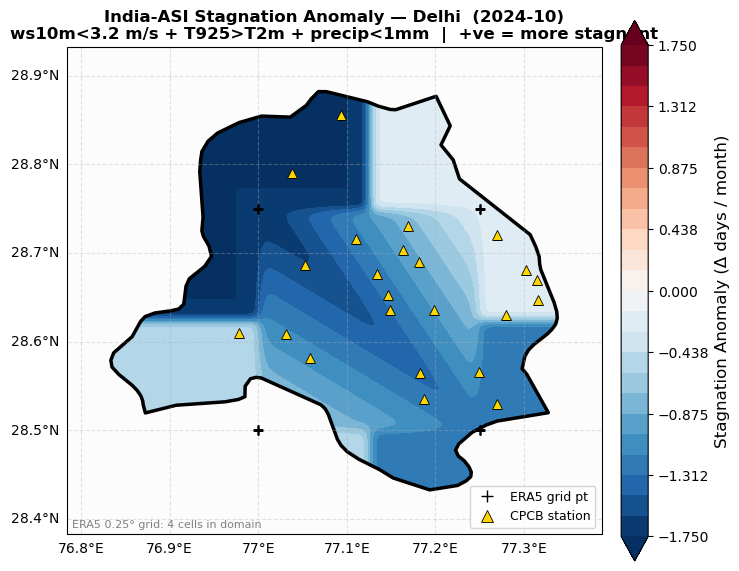


[2024-11] ERA5 raw anomaly values: [-5.   -3.75 -5.5  -6.  ]
  range: -6.000 to -3.750 stagnant days


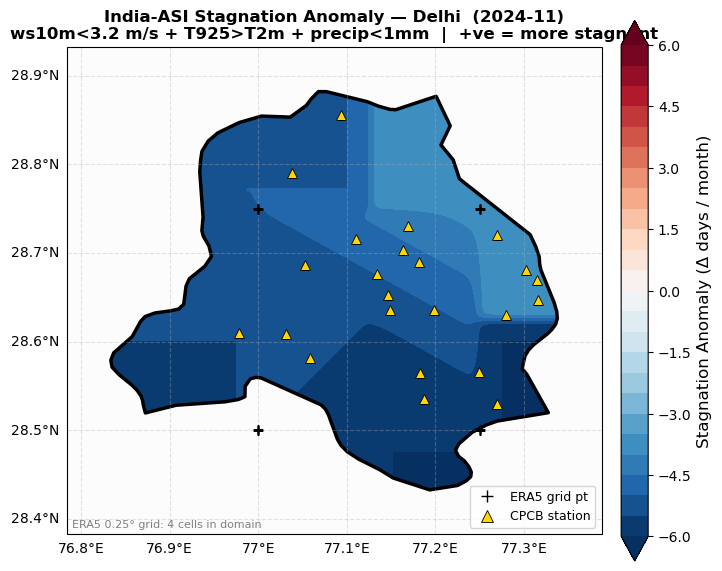


[2024-12] ERA5 raw anomaly values: [ 2.25  1.   -1.75 -0.75]
  range: -1.750 to 2.250 stagnant days


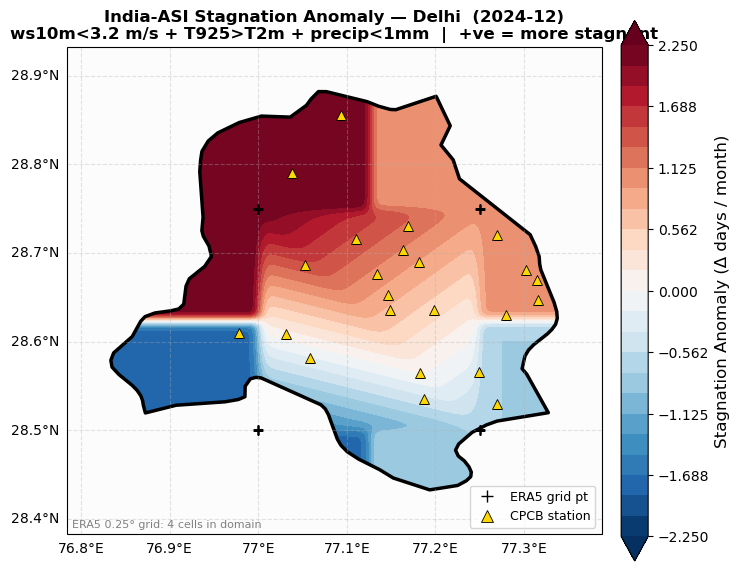


[2024-01] ERA5 raw anomaly values: [ 7.5   8.75  7.5  11.25]
  range: 7.500 to 11.250 stagnant days


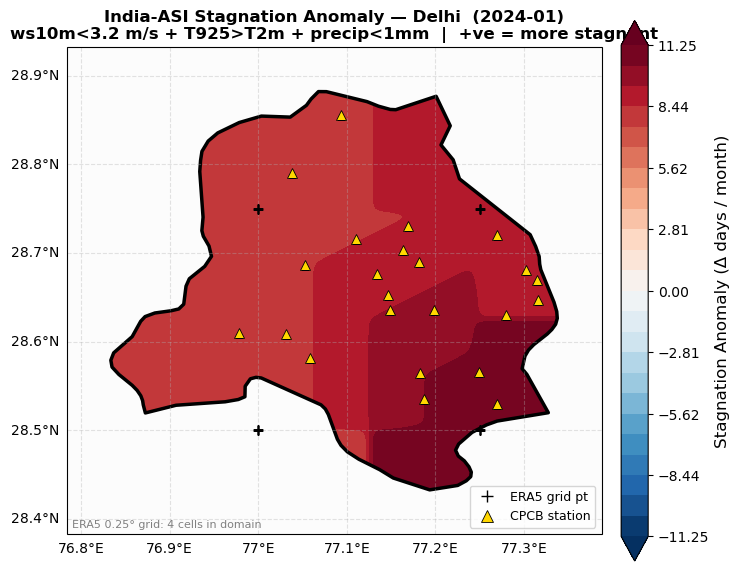


[2024-02] ERA5 raw anomaly values: [-4.75 -5.   -3.25 -4.  ]
  range: -5.000 to -3.250 stagnant days


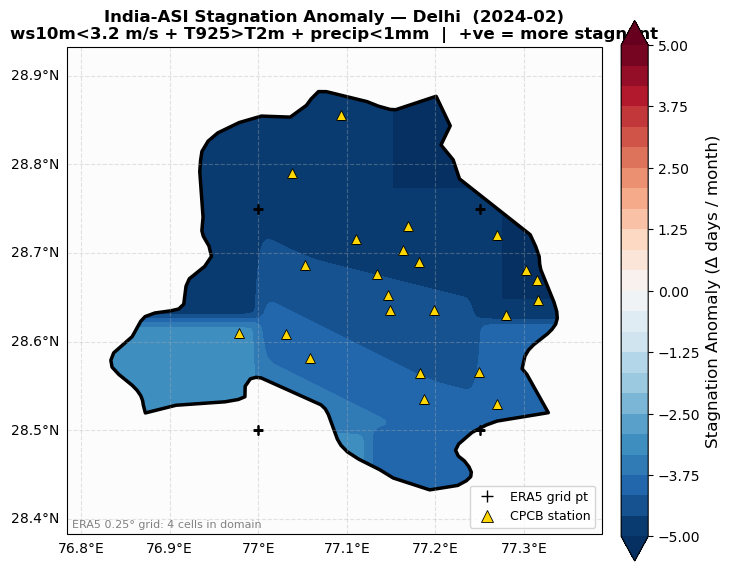


Month 10 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[1.75 1.25]
 [0.5  1.25]]
  Domain average: 1.19 days

Month 11 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[9.   8.75]
 [7.5  8.  ]]
  Domain average: 8.31 days

Month 12 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[15.75 16.  ]
 [13.75 13.75]]
  Domain average: 14.81 days

Month 01 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[8.5  9.25]
 [7.5  8.75]]
  Domain average: 8.50 days

Month 02 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[8.75 8.  ]
 [6.25 7.  ]]
  Domain average: 7.50 days


In [16]:
# ============================================================
# 5) Resample to monthly counts, filter Oct–Feb
# ============================================================
stagnant_count = stagnant_mask.resample(time="ME").sum()

stagnant_count = stagnant_count.sel(
    time=stagnant_count["time"].dt.month.isin([10, 11, 12, 1, 2])
)

print(f"Stagnant count shape: {stagnant_count.shape}")
print(f"Months present: {np.unique(stagnant_count['time'].dt.month.values)}")
print(f"Years present:  {np.unique(stagnant_count['time'].dt.year.values)}")
print(f"\nSample values (Oct 2021):\n{stagnant_count.sel(time='2021-10').values}")

# ============================================================
# 6) Climatology and anomaly
# ============================================================
climatology = stagnant_count.groupby("time.month").mean(dim="time")
anomaly     = stagnant_count.groupby("time.month") - climatology

# ============================================================
# 7–8) Geometry mask + Station coords (same as before)
# ============================================================
def geometry_mask(geom, x, y):
    pts  = np.column_stack([x.ravel(), y.ravel()])
    mask = np.zeros(len(pts), dtype=bool)
    polys = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]
    for poly in polys:
        ext    = Path(np.asarray(poly.exterior.coords))
        inside = ext.contains_points(pts)
        for hole in poly.interiors:
            inside &= ~Path(np.asarray(hole.coords)).contains_points(pts)
        mask |= inside
    return mask.reshape(x.shape)

STATION_COORDS = {
    "Rohini":        (28.7157, 77.1100),
    "Jahangirpuri":  (28.7302, 77.1693),
    "Ashok Vihar":   (28.6900, 77.1813),
    "Wazirpur":      (28.7028, 77.1632),
    "Narela":        (28.8555, 77.0940),
    "Bawana":        (28.7900, 77.0380),
    "IHBAS":         (28.6812, 77.3025),
    "Anand Vihar":   (28.6470, 77.3157),
    "Patparganj":    (28.6300, 77.2800),
    "Vivek Vihar":   (28.6690, 77.3150),
    "Sonia Vihar":   (28.7200, 77.2700),
    "Pusa":          (28.6356, 77.1492),
    "Mandir Marg":   (28.6360, 77.1980),
    "RK Puram":      (28.5640, 77.1822),
    "Okhla Ph2":     (28.5300, 77.2700),
    "Nehru Nagar":   (28.5660, 77.2490),
    "Sri Aurobindo": (28.5350, 77.1870),
    "Shadipur":      (28.6530, 77.1470),
    "NSIT Dwarka":   (28.6080, 77.0310),
    "Punjabi Bagh":  (28.6760, 77.1340),
    "Dwarka Sec8":   (28.5810, 77.0590),
    "Najafgarh":     (28.6100, 76.9780),
    "Mundka":        (28.6860, 77.0530),
}

# ============================================================
# 9) Plot function
# ============================================================
def plot_stagnation_map(year, month, show_stations=True):

    anom_plot = anomaly.sel(time=f"{year}-{month:02d}")

    ngrid      = 300
    grid_lon   = np.linspace(LON[0], LON[1], ngrid)
    grid_lat   = np.linspace(LAT[0], LAT[1], ngrid)
    grid_lon2d, grid_lat2d = np.meshgrid(grid_lon, grid_lat)

    lon2d, lat2d = np.meshgrid(
        anom_plot.longitude.values,
        anom_plot.latitude.values
    )
    points = np.column_stack([lon2d.ravel(), lat2d.ravel()])
    values = anom_plot.values.ravel()

    print(f"\n[{year}-{month:02d}] ERA5 raw anomaly values: {values}")
    print(f"  range: {values.min():.3f} to {values.max():.3f} stagnant days")

    grid_z    = griddata(points, values, (grid_lon2d, grid_lat2d), method="linear")
    grid_z_nn = griddata(points, values, (grid_lon2d, grid_lat2d), method="nearest")
    grid_z    = np.where(np.isnan(grid_z), grid_z_nn, grid_z)
    grid_z    = gaussian_filter(grid_z, sigma=3)

    inside        = geometry_mask(delhi_geom, grid_lon2d, grid_lat2d)
    grid_z_masked = np.where(inside, grid_z, np.nan)

    vmax   = max(np.nanpercentile(np.abs(grid_z_masked), 98), 0.1)
    levels = np.linspace(-vmax, vmax, 25)

    fig = plt.figure(figsize=(9, 9))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    contour = ax.contourf(
        grid_lon2d, grid_lat2d, grid_z_masked,
        levels=levels, cmap="RdBu_r", extend="both",
        transform=ccrs.PlateCarree()
    )

    ax.add_geometries(
        [delhi_geom], crs=ccrs.PlateCarree(),
        facecolor="none", edgecolor="black", linewidth=2.5
    )
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="gray")
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke", alpha=0.25)

    ax.scatter(
        lon2d.ravel(), lat2d.ravel(),
        s=60, color="k", marker="+", linewidths=1.8,
        transform=ccrs.PlateCarree(), zorder=5
    )

    if show_stations:
        for name, (slat, slon) in STATION_COORDS.items():
            ax.plot(
                slon, slat, "^", ms=7, color="gold",
                markeredgecolor="k", markeredgewidth=0.6,
                transform=ccrs.PlateCarree(), zorder=6
            )

    ax.set_extent([LON[0], LON[1], LAT[0], LAT[1]])

    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.35)
    gl.top_labels   = False
    gl.right_labels = False

    cbar = plt.colorbar(contour, ax=ax, shrink=0.78, pad=0.03)
    cbar.set_label("Stagnation Anomaly (Δ days / month)", fontsize=12)

    n_cells = len(anom_plot.latitude) * len(anom_plot.longitude)
    ax.text(
        0.01, 0.01,
        f"ERA5 0.25° grid: {n_cells} cells in domain",
        transform=ax.transAxes, fontsize=8, color="gray", va="bottom"
    )

    legend_elements = [
        Line2D([0], [0], marker="+", color="k", label="ERA5 grid pt",
               linestyle="None", ms=9),
        Line2D([0], [0], marker="^", color="gold", label="CPCB station",
               linestyle="None", ms=8, markeredgecolor="k", markeredgewidth=0.6),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

    plt.title(
        f"India-ASI Stagnation Anomaly — Delhi  ({year}-{month:02d})\n"
        f"ws10m<3.2 m/s + T925>T2m + precip<1mm  |  +ve = more stagnant",
        fontsize=12, weight="bold"
    )

    plt.subplots_adjust(right=0.85)
    plt.savefig(
        f"stagnation_anomaly_asi_{year}_{month:02d}.png",
        dpi=96, bbox_inches="tight"
    )
    plt.show()
    plt.close()

# ============================================================
# 10) Run all plots
# ============================================================
for year in [2021, 2022, 2023, 2024]:
    for month in [10, 11, 12, 1, 2]:
        try:
            plot_stagnation_map(year, month)
        except KeyError:
            print(f"No data for {year}-{month:02d}, skipping.")

# ============================================================
# 11) Print climatology
# ============================================================
for m in [10, 11, 12, 1, 2]:
    print(f"\nMonth {m:02d} — Climatology (mean India-ASI stagnant days per cell):")
    print(f"  Lats: {climatology.latitude.values}")
    print(f"  Lons: {climatology.longitude.values}")
    print(climatology.sel(month=m).values)
    print(f"  Domain average: {float(climatology.sel(month=m).mean()):.2f} days")

In [18]:
for m in [10, 11, 12, 1, 2]:
    print(f"\nMonth {m:02d} — Climatology (mean India-ASI stagnant days per cell):")
    print(f"  Lats: {climatology.latitude.values}")
    print(f"  Lons: {climatology.longitude.values}")
    print(climatology.sel(month=m).values)
    print(f"  Domain average: {float(climatology.sel(month=m).mean()):.2f} days")


Month 10 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[1.75 1.25]
 [0.5  1.25]]
  Domain average: 1.19 days

Month 11 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[9.   8.75]
 [7.5  8.  ]]
  Domain average: 8.31 days

Month 12 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[15.75 16.  ]
 [13.75 13.75]]
  Domain average: 14.81 days

Month 01 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[8.5  9.25]
 [7.5  8.75]]
  Domain average: 8.50 days

Month 02 — Climatology (mean India-ASI stagnant days per cell):
  Lats: [28.75 28.5 ]
  Lons: [77.   77.25]
[[8.75 8.  ]
 [6.25 7.  ]]
  Domain average: 7.50 days


In [17]:
for m in [10, 11, 12, 1, 2]:
    month_mask = wind_delhi.time.dt.month == m
    pct_wind = float(cond_wind.sel(time=month_mask).mean()) * 100
    pct_inv  = float(cond_inversion.sel(time=month_mask).mean()) * 100
    pct_dry  = float(cond_dry.sel(time=month_mask).mean()) * 100
    pct_all  = float(stagnant_mask.sel(time=month_mask).mean()) * 100
    print(f"Month {m:02d}: wind={pct_wind:.1f}%  inversion={pct_inv:.1f}%  dry={pct_dry:.1f}%  ALL={pct_all:.1f}%")

Month 10: wind=97.0%  inversion=4.8%  dry=75.8%  ALL=3.8%
Month 11: wind=99.0%  inversion=30.0%  dry=86.2%  ALL=27.7%
Month 12: wind=90.9%  inversion=58.3%  dry=79.2%  ALL=47.8%
Month 01: wind=87.7%  inversion=41.7%  dry=54.8%  ALL=27.4%
Month 02: wind=86.1%  inversion=33.2%  dry=72.8%  ALL=26.5%


In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# STEP 2A: Load CPCB station data
# ============================================================

CLEAN_DIR = r"D:\asd390\delhi_ground_atmos_project\final_station_data_clean"

# Region mapping (matches your PPT slide 20 — all 26 stations)
REGIONS = {
    "North":         ["1430", "1423", "1420", "1434", "1426", "1560"],
    "East":          ["114", "301", "1431", "1435", "1432", "1563"],
    "South_Central": ["122", "1424", "1425", "124", "1428", "1429", "1562", "1421"],
    "West_SW":       ["113", "115", "125", "1422", "1427", "1561"],
}

all_daily = []

for folder in os.listdir(CLEAN_DIR):
    folder_path = os.path.join(CLEAN_DIR, folder)
    if not os.path.isdir(folder_path):
        continue
    
    # Extract site_id: "station_301_anand_vihar..." → "301"
    parts = folder.split("_")
    site_id = parts[1]   # second element after splitting by _
    
    # Find region
    region = "Unknown"
    for reg, ids in REGIONS.items():
        if site_id in ids:
            region = reg
            break
    
    for f in os.listdir(folder_path):
        if not f.endswith(".csv"):
            continue
        df = pd.read_csv(os.path.join(folder_path, f))
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df["date"] = df["timestamp"].dt.date
        
        daily = df.groupby("date")["PM 2.5"].mean().reset_index()
        daily.columns = ["date", "pm25"]
        daily["site_id"] = site_id
        daily["region"] = region
        all_daily.append(daily)

cpcb = pd.concat(all_daily, ignore_index=True)
cpcb["date"] = pd.to_datetime(cpcb["date"])

print(f"CPCB daily records: {len(cpcb)}")
print(f"Stations: {cpcb['site_id'].nunique()}")
print(f"Regions: {cpcb['region'].value_counts().to_dict()}")
print(f"Date range: {cpcb['date'].min()} to {cpcb['date'].max()}")

# ============================================================
# STEP 2B: Create daily stagnation flag from ERA5
# ============================================================

daily_stag = stagnant_mask.mean(dim=["latitude", "longitude"])
daily_stag_df = daily_stag.to_dataframe(name="stag_frac").reset_index()
daily_stag_df["date"] = pd.to_datetime(daily_stag_df["time"])
daily_stag_df["is_stagnant"] = daily_stag_df["stag_frac"] > 0.5
daily_stag_df = daily_stag_df[["date", "stag_frac", "is_stagnant"]]

print(f"\nERA5 stagnation days: {daily_stag_df['is_stagnant'].sum()} / {len(daily_stag_df)}")

# ============================================================
# STEP 2C: Merge CPCB + stagnation
# ============================================================

network_daily = cpcb.groupby("date")["pm25"].mean().reset_index()
merged = network_daily.merge(daily_stag_df, on="date", how="inner")
merged["month"] = merged["date"].dt.month
merged = merged[merged["month"].isin([10, 11, 12, 1, 2])].copy()

print(f"\nMerged records (Oct-Feb): {len(merged)}")
print(f"  Stagnant days: {merged['is_stagnant'].sum()}")
print(f"  Non-stagnant days: {(~merged['is_stagnant']).sum()}")

# Quick sanity check
stag_mean = merged.loc[merged["is_stagnant"], "pm25"].mean()
nonstag_mean = merged.loc[~merged["is_stagnant"], "pm25"].mean()
print(f"\n--- KEY RESULT ---")
print(f"  PM2.5 on STAGNANT days:     {stag_mean:.1f} µg/m³")
print(f"  PM2.5 on NON-STAGNANT days: {nonstag_mean:.1f} µg/m³")
print(f"  Difference:                  +{stag_mean - nonstag_mean:.1f} µg/m³ ({(stag_mean/nonstag_mean - 1)*100:.1f}% higher)")

CPCB daily records: 37986
Stations: 26
Regions: {'South_Central': 11688, 'West_SW': 8766, 'East': 8766, 'North': 8766}
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00

ERA5 stagnation days: 174 / 1461

Merged records (Oct-Feb): 605
  Stagnant days: 146
  Non-stagnant days: 459

--- KEY RESULT ---
  PM2.5 on STAGNANT days:     259.2 µg/m³
  PM2.5 on NON-STAGNANT days: 210.5 µg/m³
  Difference:                  +48.7 µg/m³ (23.1% higher)


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_17136\1284154598.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_nonstag, data_stag],


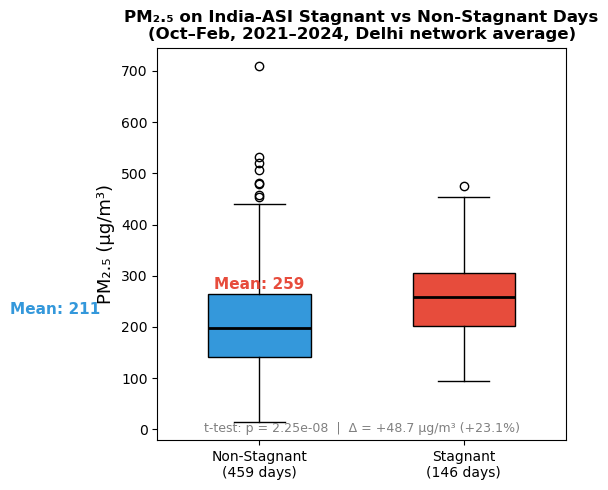

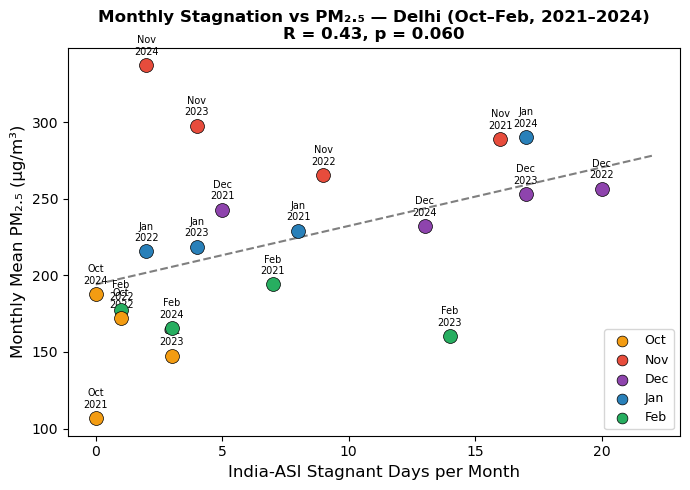


Monthly correlation: R = 0.427, p = 0.0604
Slope: +3.8 µg/m³ per stagnant day


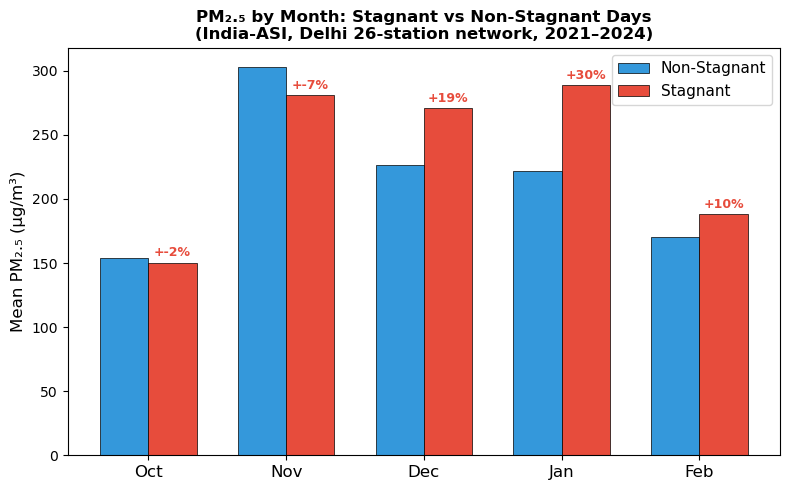

In [20]:
# ============================================================
# PLOT 1: Box plot — Stagnant vs Non-stagnant PM2.5
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))

data_stag = merged.loc[merged["is_stagnant"], "pm25"].dropna()
data_nonstag = merged.loc[~merged["is_stagnant"], "pm25"].dropna()

bp = ax.boxplot([data_nonstag, data_stag],
                labels=["Non-Stagnant\n(459 days)", "Stagnant\n(146 days)"],
                patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2))

bp["boxes"][0].set_facecolor("#3498DB")
bp["boxes"][1].set_facecolor("#E74C3C")

ax.set_ylabel("PM₂.₅ (µg/m³)", fontsize=13)
ax.set_title("PM₂.₅ on India-ASI Stagnant vs Non-Stagnant Days\n(Oct–Feb, 2021–2024, Delhi network average)", 
             fontsize=12, weight="bold")

ax.text(1, stag_mean + 15, f"Mean: {stag_mean:.0f}", ha="center", fontsize=11, color="#E74C3C", weight="bold")
ax.text(0, nonstag_mean + 15, f"Mean: {nonstag_mean:.0f}", ha="center", fontsize=11, color="#3498DB", weight="bold")

# Significance test
t_stat, p_val = stats.ttest_ind(data_stag, data_nonstag)
ax.text(0.5, 0.02, f"t-test: p = {p_val:.2e}  |  Δ = +{stag_mean-nonstag_mean:.1f} µg/m³ (+{(stag_mean/nonstag_mean-1)*100:.1f}%)",
        transform=ax.transAxes, ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("asi_validation_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 2: Monthly correlation — stagnant days vs mean PM2.5
# ============================================================
monthly = merged.groupby([merged["date"].dt.year.rename("year"), 
                          merged["date"].dt.month.rename("month")]).agg(
    pm25_mean=("pm25", "mean"),
    stag_days=("is_stagnant", "sum"),
    total_days=("is_stagnant", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))

month_colors = {10: "#F39C12", 11: "#E74C3C", 12: "#8E44AD", 1: "#2980B9", 2: "#27AE60"}
month_names = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb"}

for _, row in monthly.iterrows():
    m = int(row["month"])
    ax.scatter(row["stag_days"], row["pm25_mean"], 
              color=month_colors[m], s=100, zorder=5, edgecolors="black", linewidths=0.5)
    ax.annotate(f"{month_names[m]}\n{int(row['year'])}", 
               (row["stag_days"], row["pm25_mean"]),
               fontsize=7, ha="center", va="bottom", xytext=(0, 6), textcoords="offset points")

# Regression line
slope, intercept, r, p, se = stats.linregress(monthly["stag_days"], monthly["pm25_mean"])
x_line = np.linspace(0, monthly["stag_days"].max() + 2, 50)
ax.plot(x_line, intercept + slope * x_line, "k--", alpha=0.5, linewidth=1.5)

ax.set_xlabel("India-ASI Stagnant Days per Month", fontsize=12)
ax.set_ylabel("Monthly Mean PM₂.₅ (µg/m³)", fontsize=12)
ax.set_title("Monthly Stagnation vs PM₂.₅ — Delhi (Oct–Feb, 2021–2024)\n"
             f"R = {r:.2f}, p = {p:.3f}", fontsize=12, weight="bold")

# Legend
for m, c in month_colors.items():
    ax.scatter([], [], color=c, s=60, label=month_names[m], edgecolors="black", linewidths=0.5)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("asi_monthly_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMonthly correlation: R = {r:.3f}, p = {p:.4f}")
print(f"Slope: +{slope:.1f} µg/m³ per stagnant day")

# ============================================================
# PLOT 3: Per-month stagnant vs non-stagnant bar chart
# ============================================================
cpcb_merged = cpcb.merge(daily_stag_df, on="date", how="inner")
cpcb_merged["month"] = cpcb_merged["date"].dt.month
cpcb_merged = cpcb_merged[cpcb_merged["month"].isin([10, 11, 12, 1, 2])].copy()

monthly_comp = cpcb_merged.groupby(["month", "is_stagnant"])["pm25"].mean().unstack()
monthly_comp.columns = ["Non-Stagnant", "Stagnant"]
monthly_comp = monthly_comp.reindex([10, 11, 12, 1, 2])

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(5)
w = 0.35
bars1 = ax.bar(x - w/2, monthly_comp["Non-Stagnant"], w, label="Non-Stagnant", color="#3498DB", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + w/2, monthly_comp["Stagnant"], w, label="Stagnant", color="#E74C3C", edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(["Oct", "Nov", "Dec", "Jan", "Feb"], fontsize=12)
ax.set_ylabel("Mean PM₂.₅ (µg/m³)", fontsize=12)
ax.set_title("PM₂.₅ by Month: Stagnant vs Non-Stagnant Days\n(India-ASI, Delhi 26-station network, 2021–2024)", 
             fontsize=12, weight="bold")
ax.legend(fontsize=11)

# Add percentage labels
for i, m in enumerate([10, 11, 12, 1, 2]):
    ns = monthly_comp.loc[m, "Non-Stagnant"]
    s = monthly_comp.loc[m, "Stagnant"]
    if not np.isnan(s):
        pct = (s / ns - 1) * 100
        ax.text(i + w/2, s + 5, f"+{pct:.0f}%", ha="center", fontsize=9, color="#E74C3C", weight="bold")

plt.tight_layout()
plt.savefig("asi_monthly_barplot.png", dpi=150, bbox_inches="tight")
plt.show()